## LongTerm Memory

LongTerm 

>> Across Thread 
   >> Across Session

namespace >> (my_mem1,"preferences")
    memory_name
             >> data{
                 
             }
              >> key:value

**Long-term memory** enables agents to retain information across multiple threads/ and sessions. Unlike short-term memory, which is thread-scoped, long-term memory is stored in custom namespaces and can be accessed across different threads. Long-term memory is managed through **"stores"** that facilitate saving and retrieving memories.

    Long-term memory serves to store user-specific facts, experiences, and rules, making interactions more personalized. It can be used to:

- Store semantic memory (factual data),

- Capture episodic memory (user interactions),

- Keep track of procedural memory (how tasks are done).

### Memory Types in LangGraph

| **Memory Type** | **Stored Data** | **Human Example**                      | **Agent Example**     |
| --------------- | --------------- | -------------------------------------- | --------------------- |
| **Semantic**    | Facts           | Learned knowledge (e.g., school facts) | User-specific facts   |
| **Episodic**    | Experiences     | Past events                            | Past agent actions    |
| **Procedural**  | Instructions    | Skills (e.g., riding a bike)           | Agent's system prompt |



### Semantic Memory

Stores facts and concepts. For humans, it’s knowledge like what’s learned in school. For AI agents, it’s personalized user data.

* **Profile**: A continuously updated JSON document for specific user or system data.
* **Collection**: A series of documents that are updated over time, improving recall but adding complexity in management.



### Episodic Memory

Recalls past actions or events. Used to improve task performance by learning from past interactions. Typically implemented with **few-shot learning**, where past examples help refine agent behavior.



### Procedural Memory

Stores rules and processes for task performance, like how to complete specific tasks. Agents often update their **prompts** based on feedback, allowing them to adapt over time.



### Memory Storage

Memories are stored in **memory stores** with **namespaces** and **keys** for efficient management. LangGraph supports **semantic search** and **content filtering** for flexible retrieval.



LangGraph’s memory system uses semantic, episodic, and procedural memory to help agents remember facts, learn from past interactions, and refine tasks, resulting in more personalized and efficient responses.


In [ ]:
Embeddings >>

## Example 1

In [ ]:
BaseStore
 >> InMemory Store
   
 >> MondoDB Store

In [18]:
from langgraph.store.memory import InMemoryStore

# Define a dummy embedding function (replace with real embeddings)
def embed(texts: list[str]) -> list[list[float]]:
    return [[1.0, 2.0] * len(texts)]
    
# Create the store with semantic search enabled
store = InMemoryStore(index={"embed": embed, "dims": 2})

# Define namespace and key
namespace = ("user_123", "preferences")
memory_key = "user_profile"

# Store long-term memory
store.put(
    namespace,
    memory_key,
    {
        "name": "USER-2",
        "preferences": ["short responses", "English", "Python"]
    }    
)

# Retrieve memory
retrieved = store.get(namespace, memory_key)

print("Retrieved Memory:", retrieved)



Retrieved Memory: Item(namespace=['user_123', 'preferences'], key='user_profile', value={'name': 'USER-2', 
'preferences': ['short responses', 'English', 'Python']}, created_at='2026-03-13T04:37:18.497034+00:00', 
updated_at='2026-03-13T04:37:18.497036+00:00')

In [20]:
# Semantic search example
results = store.search(namespace, query="language preference", limit=1)
print("Semantic Search Result:", results)


Semantic Search Result:
[
    Item(namespace=['user_123', 'preferences'], key='user_profile', value={'name': 'USER-2', 'preferences': ['short
responses', 'English', 'Python']}, created_at='2026-03-13T04:37:18.497034+00:00', 
updated_at='2026-03-13T04:37:18.497036+00:00', score=0.9999999999999998)
]

## TERMS

namespace = ("user_123", "preferences")
memory_key = "user_profile"

store.put(
    namespace,
    memory_key,
    {
        "name": "USER-2",
        "preferences": ["short responses", "English", "Python"]
    }
)
- A namespace (("user_123", "preferences")) is defined, which is a tuple used to uniquely identify the "space" where this memory will be stored. It allows for organizing data based on users or specific categories.

- A memory key (user_profile) is used to identify the particular piece of data being stored in that namespace.

    - The store.put() function is used to store data. In this case, the information stored is:

    - name: "USER-2"

    - preferences: A list of preferences (["short responses", "English", "Python"]).

This is storing user-specific preferences in the in-memory store under the user_123 namespace and user_profile key.

## Example 2

In [21]:
from langchain_aws import BedrockEmbeddings
#cohere.embed-english-v3  
# Initialize the AWS Bedrock for generating embeddings

embedding_model = BedrockEmbeddings(model_id="amazon.titan-embed-text-v1", region_name="us-east-1")



In [24]:
var1=embedding_model.embed_query("Hi, we are learning langGraph.amazon.titan-embed-text-v1, import numpy as np from langgraph.store.memory import InMemoryStore")
len(var1)

1536

In [33]:
import numpy as np
from langgraph.store.memory import InMemoryStore
from typing import List
from langchain_aws import BedrockEmbeddings
#cohere.embed-english-v3  
# Initialize the AWS Bedrock for generating embeddings

embedding_model = BedrockEmbeddings(model_id="amazon.titan-embed-text-v1", region_name="us-east-1")

# Embedding function using AWS Bedrock embeddings
def embed(texts: List[str]) -> List[List[float]]:
    # Make a request to Bedrock to get embeddings for the given texts
    response = embedding_model.embed_documents({"texts": texts})
    ##print(response)
    # Convert the embeddings to a list format
    embeddings = np.array(response[:]).tolist()
    return embeddings

# Initialize InMemoryStore
embedding_dimension = 1536 # Assume the embeddings are 768-dimensional (like from BERT)
store = InMemoryStore(index={"embed": embed, "dims": embedding_dimension})

# User-specific and application context
user_id = "my-user"
application_context = "chitchat"
namespace = (user_id, application_context)

# Store long-term memory with detailed, longer text
long_text_1 = """
User enjoys learning about artificial intelligence, especially in the context of natural language processing (NLP). 
They have worked on several AI projects in Python, including building chatbots and performing sentiment analysis on large datasets. 
User likes to read research papers and keeps up with the latest advancements in AI, such as transformer models and deep learning techniques.
"""
long_text_2 = """
User prefers clear, concise communication and dislikes verbose or overly complex explanations. 
They are passionate about open-source software and contribute to multiple Python libraries in the data science ecosystem. 
While they have a technical background, they enjoy explaining complex concepts in simple terms to others. 
In addition to Python, user has worked with JavaScript for front-end web development, especially in the context of building interactive data visualizations.
"""

#  Storing longer user descriptions and preferences
store.put(
    namespace,
    "user-1-profile",
    {
        "name": "User 1",
        "bio": long_text_1,
        "preferences": "short, concise responses, AI-focused",
        "skills": ["Python", "NLP", "AI", "Data Science"],
        "languages": ["English", "German", "Tamil"],
    },
)

store.put(
    namespace,
    "user-2-profile",
    {
        "name": "User 2",
        "bio": long_text_2,
        "preferences": "clear and simple explanations, open-source contributions",
        "skills": ["Python", "JavaScript", "Data Visualization"],
        "languages": ["French", "Kannada", "Hindi"],
    },
)

store.put(
    namespace,
    "user-3-profile",
    {
        "name": "User 3",
        "bio": long_text_1,
        "preferences": "clear and simple explanations",
        "skills": ["Python", "JavaScript", "Data Visualization"],
        "languages": ["French", "Kannada", "Hindi"],
    },
)



[
    [
        -0.396484375,
        -0.04736328125,
        -0.22265625,
        0.67578125,
        0.458984375,
        0.1416015625,
        -0.296875,
        -0.000423431396484375,
        0.6640625,
        -0.33984375,
        -0.28125,
        0.80859375,
        0.30078125,
        0.11279296875,
        0.0625,
        -0.443359375,
        0.12060546875,
        1.4765625,
        -0.5234375,
        -0.2314453125,
        -0.703125,
        0.1337890625,
        -1.3671875,
        0.50390625,
        0.98046875,
        0.8671875,
        0.55078125,
        -0.890625,
        0.1962890625,
        -0.4453125,
        0.34375,
        -0.73828125,
        0.25390625,
        -0.267578125,
        -0.37109375,
        -0.06787109375,
        0.27734375,
        0.271484375,
        1.8828125,
        -0.470703125,
        -0.376953125,
        -0.357421875,
        0.369140625,
        -0.54296875,
        0.53515625,
        0.1494140625,
        -0.1943359375,
        -0.5234375,
        1.2890625,
        0.82421875,
        -0.39453125,
        1.65625,
        -0.90625,
        0.66796875,
        -0.1015625,
        0.84375,
        -0.07275390625,
        0.181640625,
        0.53125,
        -0.6640625,
        0.0595703125,
        -0.94140625,
        0.59375,
        -0.703125,
        -0.5390625,
        0.0654296875,
        0.84375,
        0.53515625,
        0.89453125,
        0.0068359375,
        0.51953125,
        -0.0966796875,
        0.400390625,
        -0.54296875,
        -0.64453125,
        0.7734375,
        -0.275390625,
        -0.90625,
        0.60546875,
        -0.72265625,
        -0.37109375,
        -0.1396484375,
        -0.22265625,
        1.0390625,
        0.1748046875,
        0.083984375,
        -0.9765625,
        -0.4453125,
        0.0001220703125,
        -1.046875,
        0.19140625,
        0.7890625,
        0.034912109375,
        -0.81640625,
        -0.65234375,
        0.1982421875,
        0.07861328125,
        -0.1640625,
        0.2451171875,
        -0.357421875,
        -0.21484375,
        0.58984375,
        0.169921875,
        0.56640625,
        -0.2373046875,
        0.60546875,
        1.1171875,
        1.3203125,
        0.67578125,
        0.427734375,
        -0.498046875,
        -0.369140625,
        0.0712890625,
        -0.5078125,
        -1.2890625,
        -0.1435546875,
        0.138671875,
        -0.470703125,
        -0.3125,
        -0.1396484375,
        0.96484375,
        -0.0419921875,
        -0.298828125,
        1.0625,
        -0.050048828125,
        0.453125,
        0.458984375,
        0.53515625,
        0.6484375,
        -0.1689453125,
        0.12890625,
        0.64453125,
        0.0830078125,
        -0.609375,
        1.25,
        0.3515625,
        -1.328125,
        -0.1845703125,
        0.91796875,
        0.3984375,
        -0.578125,
        -0.30859375,
        0.30859375,
        0.166015625,
        -0.0537109375,
        0.6328125,
        -0.1806640625,
        0.5078125,
        0.0615234375,
        -1.1875,
        -0.0654296875,
        0.451171875,
        -0.357421875,
        -0.197265625,
        0.212890625,
        0.5546875,
        0.1728515625,
        -0.341796875,
        -0.62109375,
        0.828125,
        -0.0169677734375,
        0.4140625,
        -0.482421875,
        -0.203125,
        -0.1591796875,
        -0.390625,
        -0.79296875,
        0.73828125,
        -0.86328125,
        0.216796875,
        -0.328125,
        0.72265625,
        -0.1904296875,
        -0.7890625,
        0.373046875,
        0.265625,
        0.052978515625,
        -0.259765625,
        -0.70703125,
        -0.1259765625,
        0.2158203125,
        -0.2041015625,
        -0.09375,
        -0.310546875,
        1.15625,
        -0.369140625,
        -0.40234375,
        0.72265625,
        0.71484375,
        0.412109375,
        0.07568359375,
        0.58203125,
        0.2294921875

[
    [
        -0.396484375,
        -0.04736328125,
        -0.22265625,
        0.67578125,
        0.458984375,
        0.1416015625,
        -0.296875,
        -0.000423431396484375,
        0.6640625,
        -0.33984375,
        -0.28125,
        0.80859375,
        0.30078125,
        0.11279296875,
        0.0625,
        -0.443359375,
        0.12060546875,
        1.4765625,
        -0.5234375,
        -0.2314453125,
        -0.703125,
        0.1337890625,
        -1.3671875,
        0.50390625,
        0.98046875,
        0.8671875,
        0.55078125,
        -0.890625,
        0.1962890625,
        -0.4453125,
        0.34375,
        -0.73828125,
        0.25390625,
        -0.267578125,
        -0.37109375,
        -0.06787109375,
        0.27734375,
        0.271484375,
        1.8828125,
        -0.470703125,
        -0.376953125,
        -0.357421875,
        0.369140625,
        -0.54296875,
        0.53515625,
        0.1494140625,
        -0.1943359375,
        -0.5234375,
        1.2890625,
        0.82421875,
        -0.39453125,
        1.65625,
        -0.90625,
        0.66796875,
        -0.1015625,
        0.84375,
        -0.07275390625,
        0.181640625,
        0.53125,
        -0.6640625,
        0.0595703125,
        -0.94140625,
        0.59375,
        -0.703125,
        -0.5390625,
        0.0654296875,
        0.84375,
        0.53515625,
        0.89453125,
        0.0068359375,
        0.51953125,
        -0.0966796875,
        0.400390625,
        -0.54296875,
        -0.64453125,
        0.7734375,
        -0.275390625,
        -0.90625,
        0.60546875,
        -0.72265625,
        -0.37109375,
        -0.1396484375,
        -0.22265625,
        1.0390625,
        0.1748046875,
        0.083984375,
        -0.9765625,
        -0.4453125,
        0.0001220703125,
        -1.046875,
        0.19140625,
        0.7890625,
        0.034912109375,
        -0.81640625,
        -0.65234375,
        0.1982421875,
        0.07861328125,
        -0.1640625,
        0.2451171875,
        -0.357421875,
        -0.21484375,
        0.58984375,
        0.169921875,
        0.56640625,
        -0.2373046875,
        0.60546875,
        1.1171875,
        1.3203125,
        0.67578125,
        0.427734375,
        -0.498046875,
        -0.369140625,
        0.0712890625,
        -0.5078125,
        -1.2890625,
        -0.1435546875,
        0.138671875,
        -0.470703125,
        -0.3125,
        -0.1396484375,
        0.96484375,
        -0.0419921875,
        -0.298828125,
        1.0625,
        -0.050048828125,
        0.453125,
        0.458984375,
        0.53515625,
        0.6484375,
        -0.1689453125,
        0.12890625,
        0.64453125,
        0.0830078125,
        -0.609375,
        1.25,
        0.3515625,
        -1.328125,
        -0.1845703125,
        0.91796875,
        0.3984375,
        -0.578125,
        -0.30859375,
        0.30859375,
        0.166015625,
        -0.0537109375,
        0.6328125,
        -0.1806640625,
        0.5078125,
        0.0615234375,
        -1.1875,
        -0.0654296875,
        0.451171875,
        -0.357421875,
        -0.197265625,
        0.212890625,
        0.5546875,
        0.1728515625,
        -0.341796875,
        -0.62109375,
        0.828125,
        -0.0169677734375,
        0.4140625,
        -0.482421875,
        -0.203125,
        -0.1591796875,
        -0.390625,
        -0.79296875,
        0.73828125,
        -0.86328125,
        0.216796875,
        -0.328125,
        0.72265625,
        -0.1904296875,
        -0.7890625,
        0.373046875,
        0.265625,
        0.052978515625,
        -0.259765625,
        -0.70703125,
        -0.1259765625,
        0.2158203125,
        -0.2041015625,
        -0.09375,
        -0.310546875,
        1.15625,
        -0.369140625,
        -0.40234375,
        0.72265625,
        0.71484375,
        0.412109375,
        0.07568359375,
        0.58203125,
        0.2294921875

[
    [
        -0.396484375,
        -0.04736328125,
        -0.22265625,
        0.67578125,
        0.458984375,
        0.1416015625,
        -0.296875,
        -0.000423431396484375,
        0.6640625,
        -0.33984375,
        -0.28125,
        0.80859375,
        0.30078125,
        0.11279296875,
        0.0625,
        -0.443359375,
        0.12060546875,
        1.4765625,
        -0.5234375,
        -0.2314453125,
        -0.703125,
        0.1337890625,
        -1.3671875,
        0.50390625,
        0.98046875,
        0.8671875,
        0.55078125,
        -0.890625,
        0.1962890625,
        -0.4453125,
        0.34375,
        -0.73828125,
        0.25390625,
        -0.267578125,
        -0.37109375,
        -0.06787109375,
        0.27734375,
        0.271484375,
        1.8828125,
        -0.470703125,
        -0.376953125,
        -0.357421875,
        0.369140625,
        -0.54296875,
        0.53515625,
        0.1494140625,
        -0.1943359375,
        -0.5234375,
        1.2890625,
        0.82421875,
        -0.39453125,
        1.65625,
        -0.90625,
        0.66796875,
        -0.1015625,
        0.84375,
        -0.07275390625,
        0.181640625,
        0.53125,
        -0.6640625,
        0.0595703125,
        -0.94140625,
        0.59375,
        -0.703125,
        -0.5390625,
        0.0654296875,
        0.84375,
        0.53515625,
        0.89453125,
        0.0068359375,
        0.51953125,
        -0.0966796875,
        0.400390625,
        -0.54296875,
        -0.64453125,
        0.7734375,
        -0.275390625,
        -0.90625,
        0.60546875,
        -0.72265625,
        -0.37109375,
        -0.1396484375,
        -0.22265625,
        1.0390625,
        0.1748046875,
        0.083984375,
        -0.9765625,
        -0.4453125,
        0.0001220703125,
        -1.046875,
        0.19140625,
        0.7890625,
        0.034912109375,
        -0.81640625,
        -0.65234375,
        0.1982421875,
        0.07861328125,
        -0.1640625,
        0.2451171875,
        -0.357421875,
        -0.21484375,
        0.58984375,
        0.169921875,
        0.56640625,
        -0.2373046875,
        0.60546875,
        1.1171875,
        1.3203125,
        0.67578125,
        0.427734375,
        -0.498046875,
        -0.369140625,
        0.0712890625,
        -0.5078125,
        -1.2890625,
        -0.1435546875,
        0.138671875,
        -0.470703125,
        -0.3125,
        -0.1396484375,
        0.96484375,
        -0.0419921875,
        -0.298828125,
        1.0625,
        -0.050048828125,
        0.453125,
        0.458984375,
        0.53515625,
        0.6484375,
        -0.1689453125,
        0.12890625,
        0.64453125,
        0.0830078125,
        -0.609375,
        1.25,
        0.3515625,
        -1.328125,
        -0.1845703125,
        0.91796875,
        0.3984375,
        -0.578125,
        -0.30859375,
        0.30859375,
        0.166015625,
        -0.0537109375,
        0.6328125,
        -0.1806640625,
        0.5078125,
        0.0615234375,
        -1.1875,
        -0.0654296875,
        0.451171875,
        -0.357421875,
        -0.197265625,
        0.212890625,
        0.5546875,
        0.1728515625,
        -0.341796875,
        -0.62109375,
        0.828125,
        -0.0169677734375,
        0.4140625,
        -0.482421875,
        -0.203125,
        -0.1591796875,
        -0.390625,
        -0.79296875,
        0.73828125,
        -0.86328125,
        0.216796875,
        -0.328125,
        0.72265625,
        -0.1904296875,
        -0.7890625,
        0.373046875,
        0.265625,
        0.052978515625,
        -0.259765625,
        -0.70703125,
        -0.1259765625,
        0.2158203125,
        -0.2041015625,
        -0.09375,
        -0.310546875,
        1.15625,
        -0.369140625,
        -0.40234375,
        0.72265625,
        0.71484375,
        0.412109375,
        0.07568359375,
        0.58203125,
        0.2294921875

In [34]:
#  Retrieve the memory by ID
item = store.get(namespace, "user-1-profile")
print("Retrieved User 1 Profile:")
print(item)

item = store.get(namespace, "user-2-profile")
print("\nRetrieved User 2 Profile:")
print(item)


Retrieved User 1 Profile:

Item(namespace=['my-user', 'chitchat'], key='user-1-profile', value={'name': 'User 1', 'bio': '\nUser enjoys 
learning about artificial intelligence, especially in the context of natural language processing (NLP). \nThey have
worked on several AI projects in Python, including building chatbots and performing sentiment analysis on large 
datasets. \nUser likes to read research papers and keeps up with the latest advancements in AI, such as transformer
models and deep learning techniques.\n', 'preferences': 'short, concise responses, AI-focused', 'skills': 
['Python', 'NLP', 'AI', 'Data Science'], 'languages': ['English', 'German', 'Tamil']}, 
created_at='2026-03-13T05:01:21.856240+00:00', updated_at='2026-03-13T05:01:21.856241+00:00')

Retrieved User 2 Profile:

Item(namespace=['my-user', 'chitchat'], key='user-2-profile', value={'name': 'User 2', 'bio': '\nUser prefers 
clear, concise communication and dislikes verbose or overly complex explanations. \nThey are passionate about 
open-source software and contribute to multiple Python libraries in the data science ecosystem. \nWhile they have a
technical background, they enjoy explaining complex concepts in simple terms to others. \nIn addition to Python, 
user has worked with JavaScript for front-end web development, especially in the context of building interactive 
data visualizations.\n', 'preferences': 'clear and simple explanations, open-source contributions', 'skills': 
['Python', 'JavaScript', 'Data Visualization'], 'languages': ['French', 'Kannada', 'Hindi']}, 
created_at='2026-03-13T05:01:22.237970+00:00', updated_at='2026-03-13T05:01:22.237972+00:00')

## Search the Store

In [35]:
items = store.search( 
    namespace, filter={"languages": ["French", "Kannada", "Hindi"]}, query="open source contributions"
)

[
    [
        -0.396484375,
        -0.04736328125,
        -0.22265625,
        0.67578125,
        0.458984375,
        0.1416015625,
        -0.296875,
        -0.000423431396484375,
        0.6640625,
        -0.33984375,
        -0.28125,
        0.80859375,
        0.30078125,
        0.11279296875,
        0.0625,
        -0.443359375,
        0.12060546875,
        1.4765625,
        -0.5234375,
        -0.2314453125,
        -0.703125,
        0.1337890625,
        -1.3671875,
        0.50390625,
        0.98046875,
        0.8671875,
        0.55078125,
        -0.890625,
        0.1962890625,
        -0.4453125,
        0.34375,
        -0.73828125,
        0.25390625,
        -0.267578125,
        -0.37109375,
        -0.06787109375,
        0.27734375,
        0.271484375,
        1.8828125,
        -0.470703125,
        -0.376953125,
        -0.357421875,
        0.369140625,
        -0.54296875,
        0.53515625,
        0.1494140625,
        -0.1943359375,
        -0.5234375,
        1.2890625,
        0.82421875,
        -0.39453125,
        1.65625,
        -0.90625,
        0.66796875,
        -0.1015625,
        0.84375,
        -0.07275390625,
        0.181640625,
        0.53125,
        -0.6640625,
        0.0595703125,
        -0.94140625,
        0.59375,
        -0.703125,
        -0.5390625,
        0.0654296875,
        0.84375,
        0.53515625,
        0.89453125,
        0.0068359375,
        0.51953125,
        -0.0966796875,
        0.400390625,
        -0.54296875,
        -0.64453125,
        0.7734375,
        -0.275390625,
        -0.90625,
        0.60546875,
        -0.72265625,
        -0.37109375,
        -0.1396484375,
        -0.22265625,
        1.0390625,
        0.1748046875,
        0.083984375,
        -0.9765625,
        -0.4453125,
        0.0001220703125,
        -1.046875,
        0.19140625,
        0.7890625,
        0.034912109375,
        -0.81640625,
        -0.65234375,
        0.1982421875,
        0.07861328125,
        -0.1640625,
        0.2451171875,
        -0.357421875,
        -0.21484375,
        0.58984375,
        0.169921875,
        0.56640625,
        -0.2373046875,
        0.60546875,
        1.1171875,
        1.3203125,
        0.67578125,
        0.427734375,
        -0.498046875,
        -0.369140625,
        0.0712890625,
        -0.5078125,
        -1.2890625,
        -0.1435546875,
        0.138671875,
        -0.470703125,
        -0.3125,
        -0.1396484375,
        0.96484375,
        -0.0419921875,
        -0.298828125,
        1.0625,
        -0.050048828125,
        0.453125,
        0.458984375,
        0.53515625,
        0.6484375,
        -0.1689453125,
        0.12890625,
        0.64453125,
        0.0830078125,
        -0.609375,
        1.25,
        0.3515625,
        -1.328125,
        -0.1845703125,
        0.91796875,
        0.3984375,
        -0.578125,
        -0.30859375,
        0.30859375,
        0.166015625,
        -0.0537109375,
        0.6328125,
        -0.1806640625,
        0.5078125,
        0.0615234375,
        -1.1875,
        -0.0654296875,
        0.451171875,
        -0.357421875,
        -0.197265625,
        0.212890625,
        0.5546875,
        0.1728515625,
        -0.341796875,
        -0.62109375,
        0.828125,
        -0.0169677734375,
        0.4140625,
        -0.482421875,
        -0.203125,
        -0.1591796875,
        -0.390625,
        -0.79296875,
        0.73828125,
        -0.86328125,
        0.216796875,
        -0.328125,
        0.72265625,
        -0.1904296875,
        -0.7890625,
        0.373046875,
        0.265625,
        0.052978515625,
        -0.259765625,
        -0.70703125,
        -0.1259765625,
        0.2158203125,
        -0.2041015625,
        -0.09375,
        -0.310546875,
        1.15625,
        -0.369140625,
        -0.40234375,
        0.72265625,
        0.71484375,
        0.412109375,
        0.07568359375,
        0.58203125,
        0.2294921875

In [36]:
from rich import print
print(items)

[
    Item(namespace=['my-user', 'chitchat'], key='user-2-profile', value={'name': 'User 2', 'bio': '\nUser prefers 
clear, concise communication and dislikes verbose or overly complex explanations. \nThey are passionate about 
open-source software and contribute to multiple Python libraries in the data science ecosystem. \nWhile they have a
technical background, they enjoy explaining complex concepts in simple terms to others. \nIn addition to Python, 
user has worked with JavaScript for front-end web development, especially in the context of building interactive 
data visualizations.\n', 'preferences': 'clear and simple explanations, open-source contributions', 'skills': 
['Python', 'JavaScript', 'Data Visualization'], 'languages': ['French', 'Kannada', 'Hindi']}, 
created_at='2026-03-13T05:01:22.237970+00:00', updated_at='2026-03-13T05:01:22.237972+00:00', score=1.0),
    Item(namespace=['my-user', 'chitchat'], key='user-3-profile', value={'name': 'User 3', 'bio': '\nUser enjoys 
learning about artificial intelligence, especially in the context of natural language processing (NLP). \nThey have
worked on several AI projects in Python, including building chatbots and performing sentiment analysis on large 
datasets. \nUser likes to read research papers and keeps up with the latest advancements in AI, such as transformer
models and deep learning techniques.\n', 'preferences': 'clear and simple explanations', 'skills': ['Python', 
'JavaScript', 'Data Visualization'], 'languages': ['French', 'Kannada', 'Hindi']}, 
created_at='2026-03-13T05:01:22.621741+00:00', updated_at='2026-03-13T05:01:22.621742+00:00', score=1.0)
]

In [37]:
items = store.search( 
    namespace, filter={"languages": ["English", "German", "Tamil"]}, query="The user who is AI focused"
)


[
    [
        -0.396484375,
        -0.04736328125,
        -0.22265625,
        0.67578125,
        0.458984375,
        0.1416015625,
        -0.296875,
        -0.000423431396484375,
        0.6640625,
        -0.33984375,
        -0.28125,
        0.80859375,
        0.30078125,
        0.11279296875,
        0.0625,
        -0.443359375,
        0.12060546875,
        1.4765625,
        -0.5234375,
        -0.2314453125,
        -0.703125,
        0.1337890625,
        -1.3671875,
        0.50390625,
        0.98046875,
        0.8671875,
        0.55078125,
        -0.890625,
        0.1962890625,
        -0.4453125,
        0.34375,
        -0.73828125,
        0.25390625,
        -0.267578125,
        -0.37109375,
        -0.06787109375,
        0.27734375,
        0.271484375,
        1.8828125,
        -0.470703125,
        -0.376953125,
        -0.357421875,
        0.369140625,
        -0.54296875,
        0.53515625,
        0.1494140625,
        -0.1943359375,
        -0.5234375,
        1.2890625,
        0.82421875,
        -0.39453125,
        1.65625,
        -0.90625,
        0.66796875,
        -0.1015625,
        0.84375,
        -0.07275390625,
        0.181640625,
        0.53125,
        -0.6640625,
        0.0595703125,
        -0.94140625,
        0.59375,
        -0.703125,
        -0.5390625,
        0.0654296875,
        0.84375,
        0.53515625,
        0.89453125,
        0.0068359375,
        0.51953125,
        -0.0966796875,
        0.400390625,
        -0.54296875,
        -0.64453125,
        0.7734375,
        -0.275390625,
        -0.90625,
        0.60546875,
        -0.72265625,
        -0.37109375,
        -0.1396484375,
        -0.22265625,
        1.0390625,
        0.1748046875,
        0.083984375,
        -0.9765625,
        -0.4453125,
        0.0001220703125,
        -1.046875,
        0.19140625,
        0.7890625,
        0.034912109375,
        -0.81640625,
        -0.65234375,
        0.1982421875,
        0.07861328125,
        -0.1640625,
        0.2451171875,
        -0.357421875,
        -0.21484375,
        0.58984375,
        0.169921875,
        0.56640625,
        -0.2373046875,
        0.60546875,
        1.1171875,
        1.3203125,
        0.67578125,
        0.427734375,
        -0.498046875,
        -0.369140625,
        0.0712890625,
        -0.5078125,
        -1.2890625,
        -0.1435546875,
        0.138671875,
        -0.470703125,
        -0.3125,
        -0.1396484375,
        0.96484375,
        -0.0419921875,
        -0.298828125,
        1.0625,
        -0.050048828125,
        0.453125,
        0.458984375,
        0.53515625,
        0.6484375,
        -0.1689453125,
        0.12890625,
        0.64453125,
        0.0830078125,
        -0.609375,
        1.25,
        0.3515625,
        -1.328125,
        -0.1845703125,
        0.91796875,
        0.3984375,
        -0.578125,
        -0.30859375,
        0.30859375,
        0.166015625,
        -0.0537109375,
        0.6328125,
        -0.1806640625,
        0.5078125,
        0.0615234375,
        -1.1875,
        -0.0654296875,
        0.451171875,
        -0.357421875,
        -0.197265625,
        0.212890625,
        0.5546875,
        0.1728515625,
        -0.341796875,
        -0.62109375,
        0.828125,
        -0.0169677734375,
        0.4140625,
        -0.482421875,
        -0.203125,
        -0.1591796875,
        -0.390625,
        -0.79296875,
        0.73828125,
        -0.86328125,
        0.216796875,
        -0.328125,
        0.72265625,
        -0.1904296875,
        -0.7890625,
        0.373046875,
        0.265625,
        0.052978515625,
        -0.259765625,
        -0.70703125,
        -0.1259765625,
        0.2158203125,
        -0.2041015625,
        -0.09375,
        -0.310546875,
        1.15625,
        -0.369140625,
        -0.40234375,
        0.72265625,
        0.71484375,
        0.412109375,
        0.07568359375,
        0.58203125,
        0.2294921875

[
    Item(namespace=['my-user', 'chitchat'], key='user-1-profile', value={'name': 'User 1', 'bio': '\nUser enjoys 
learning about artificial intelligence, especially in the context of natural language processing (NLP). \nThey have
worked on several AI projects in Python, including building chatbots and performing sentiment analysis on large 
datasets. \nUser likes to read research papers and keeps up with the latest advancements in AI, such as transformer
models and deep learning techniques.\n', 'preferences': 'short, concise responses, AI-focused', 'skills': 
['Python', 'NLP', 'AI', 'Data Science'], 'languages': ['English', 'German', 'Tamil']}, 
created_at='2026-03-13T05:01:21.856240+00:00', updated_at='2026-03-13T05:01:21.856241+00:00', score=1.0)
]

In [38]:
print(items)

[
    Item(namespace=['my-user', 'chitchat'], key='user-1-profile', value={'name': 'User 1', 'bio': '\nUser enjoys 
learning about artificial intelligence, especially in the context of natural language processing (NLP). \nThey have
worked on several AI projects in Python, including building chatbots and performing sentiment analysis on large 
datasets. \nUser likes to read research papers and keeps up with the latest advancements in AI, such as transformer
models and deep learning techniques.\n', 'preferences': 'short, concise responses, AI-focused', 'skills': 
['Python', 'NLP', 'AI', 'Data Science'], 'languages': ['English', 'German', 'Tamil']}, 
created_at='2026-03-13T05:01:21.856240+00:00', updated_at='2026-03-13T05:01:21.856241+00:00', score=1.0)
]

In [ ]:
## Financial Assistant
 >> LLM 
    >> User input 
     > previous memories  >> 1,2, 3
       >> query > search > already stored > previous responses
     > system prompt
thread 1
>>
thread 2
    >>

## Example 3

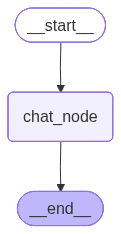

In [2]:
import time # Used to generate a unique ID for new memories

from langchain_core.messages import HumanMessage, AIMessage
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langgraph.graph import START, MessagesState, StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver

# Configure LLM and Embeddings Model

from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
model = ChatBedrockConverse(
    model_id="amazon.nova-lite-v1:0", 
    region_name="us-east-1", 
    temperature=0.4,
    max_tokens=50
)
embeddings = BedrockEmbeddings(model_id="cohere.embed-english-v3")

# Setup Store and Initial Memories ---
store = InMemoryStore(
    index={
        "embed": embeddings,
        "dims": 1536, 
    }
)
USER_ID = "user_123"

# Add specific financial memories
store.put((USER_ID, "memories"), "1", {"text": "I am generally risk-averse and prefer stability."})
store.put((USER_ID, "memories"), "2", {"text": "I am an engineer and I earn $10000 per year."})
store.put((USER_ID, "memories"), "3", {"text": "My goal is to retire in 10 years."})


def chat(state: MessagesState, *, store: BaseStore) -> dict:
    """
    Retrieves user memories, stores the latest user message, and invokes the model.
    """
    # ----------------------------------------------------
    # Store the latest user message to memory
    # ----------------------------------------------------
    latest_user_message = state["messages"][-1] 
    
    # Create a unique ID for the new memory item
    new_id = str(int(time.time() * 1000))

    # Store the new user message content
    store.put(
        (USER_ID, "memories"), # Key (user ID, memory type)
        new_id,                # Unique item ID
        {"text": latest_user_message.content} # The content to store
    )
    # print(f"[SYSTEM]: Stored new user message to memory with ID: {new_id}")

    # ----------------------------------------------------
    # Retrieve relevant memories for context
    # ----------------------------------------------------
    
    # Search based on user's last message AND the history for context
    items = store.search(
        (USER_ID, "memories"), 
        query=latest_user_message.content, 
        limit=3 
    )
    
    # Format retrieved memories
    memories = "\n".join(item.value["text"] for item in items)
    memories_prompt = f"\n## User Context/Memories\n{memories}" if memories else ""
    
    # ----------------------------------------------------
    #  Invoke the model with the financial prompt
    # ----------------------------------------------------
    system_prompt = (
        "You are a helpful, ethical, and conservative **Financial Advisor AI**. "
        "Use the provided user memories to personalize your advice. "
        "Keep your answers professional and focused on financial well-being. "
        f"{memories_prompt}"
    )

    # Invoke the model
    response = model.invoke(
        [
            {"role": "system", "content": system_prompt},
            *state["messages"],
        ]
    )
    
    return {"messages": [response]}


# --- 3. Build the Graph ---
builder = StateGraph(MessagesState)
builder.add_node("chat_node", chat)
builder.add_edge(START, "chat_node")
# Directly connect the chat node to the end, as there are no tools
builder.add_edge("chat_node", END) 
graph = builder.compile(checkpointer=InMemorySaver(),store=store)

graph

In [ ]:
# Example Conversation Run ---

print("--- STARTING FINANCIAL CHATBOT Thread 1---")
while True:
# --- First Interaction ---
    user_input = input("Your Query:")
    print(f"\nUser : {user_input}")
    if(user_input=='exit'):
        break
# This message will be processed AND stored.
    for message in graph.stream( input={"messages": [HumanMessage(content=user_input)]},
                                 config={'configurable':{'thread_id':1}},stream_mode="values",):
        
        if isinstance(message["messages"][-1], AIMessage):
            
            print("AI Advisor :", message["messages"][-1].content)

print("\n--- END OF CHATBOT ---")

In [76]:
# Example Conversation Run ---

print("--- STARTING FINANCIAL CHATBOT Thread 1---")
while True:
# --- First Interaction ---
    user_input = input("Your Query:")
    print(f"\nUser : {user_input}")
    if(user_input=='exit'):
        break
# This message will be processed AND stored.
    for message in graph.stream( input={"messages": [HumanMessage(content=user_input)]},
                                 config={'configurable':{'thread_id':1}},stream_mode="values",):
        
        if isinstance(message["messages"][-1], AIMessage):
            
            print("AI Advisor :", message["messages"][-1].content)

print("\n--- END OF CHATBOT ---")

--- STARTING FINANCIAL CHATBOT Thread 1---

Your Query: Hi


User : Hi

AI Advisor : Hello! It's great to connect with you. Given your risk-averse nature and your goal to retire in 10 
years, I'll focus on strategies that prioritize stability and capital preservation while ensuring you are on track 
to meet your

Your Query: I want to build a home in next 5 years


...

User : thank you

AI Advisor : You're welcome! If you have any more questions or need further assistance in the future, feel free to 
reach out. Good luck with your home-building plans and your retirement journey!

Your Query: exit


User : exit

--- END OF CHATBOT ---

In [77]:
# --- 4. Example Conversation Run ---

print("--- STARTING FINANCIAL CHATBOT Thread 2 ---")
while True:
# --- First Interaction ---
    user_input = input("Your Query:")
    print(f"\nUser : {user_input}")
    if(user_input=='exit'):
        break
# This message will be processed AND stored.
    for message in graph.stream( input={"messages": [HumanMessage(content=user_input)]},
                                 config={'configurable':{'thread_id':2}},stream_mode="values",):
        
        if isinstance(message["messages"][-1], AIMessage):
            
            print("AI Advisor :", message["messages"][-1].content)

print("\n--- END OF CHATBOT ---")

--- STARTING FINANCIAL CHATBOT Thread 2 ---

Your Query: Hi


User : Hi

AI Advisor : Hello! It's great to connect with you. If you have any financial questions or need advice on managing 
your finances, feel free to share the details. I'm here to help you make informed and prudent financial decisions. 
How can I assist

Your Query: I want to buy a car in next 5 years


...

User : What are my previous queries?

AI Advisor : Based on your previous queries, you've expressed interest in:

1. **Financial Feasibility:** You asked if it's possible to achieve your financial goals with your current income.
2. **Car Purchase:** You mentioned wanting to buy a car in

Your Query: exit


User : exit

--- END OF CHATBOT ---

In [81]:
# Print all memories for the user
from rich import print

def print_user_memories(store, user_id):
    # Retrieve all memories for the given user_id
    items = store.search((user_id, "memories"), query="What is my goal in next few years?", limit=2)
    print(items)# Set limit to an appropriate number if needed
    
# Call the function to print all stored memories for USER_ID
print_user_memories(store, USER_ID)


[
    Item(namespace=['user_123', 'memories'], key='3', value={'text': 'My goal is to retire in 10 years.'}, 
created_at='2025-12-07T08:00:34.234074+00:00', updated_at='2025-12-07T08:00:34.234078+00:00', 
score=0.4494777413785013),
    Item(namespace=['user_123', 'memories'], key='1765094469258', value={'text': 'I want to build a home in next 5 
years'}, created_at='2025-12-07T08:01:09.533834+00:00', updated_at='2025-12-07T08:01:09.533838+00:00', 
score=0.33015108964794393)
]